In [1662]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [1663]:
df_medios_2023 = pd.read_excel('Tablas_EAL_2023.xlsx', sheet_name='EAL-18a',header=None,skiprows=6)

df_medios_2023.columns=df_medios_2023.iloc[0] #usar la primera fila como nombre de columnas
df_medios_2023=df_medios_2023[1:] #eliminar la primera fila que ahora es el nombre de columnas
df_medios_2023 = df_medios_2023.rename(columns={df_medios_2023.columns[0]: 'categoria'}) #renombrar la columna de categorias
df_medios_2023= df_medios_2023.dropna(how='all')
df_medios_2023 = df_medios_2023[~df_medios_2023['categoria'].str.contains(r'\(1\)|\(2\)', na=False)]# eliminar filas que contienen (1) o (2) en la columna de categorias

In [1664]:
df_medios_2024 = pd.read_excel('Tablas_EAL_2024.xlsx', sheet_name='EAL-18a',header=None,skiprows=6)

df_medios_2024.columns=df_medios_2024.iloc[0] #usar la primera fila como nombre de columnas
df_medios_2024=df_medios_2024[1:] #eliminar la primera fila que ahora es el nombre de columnas
df_medios_2024 = df_medios_2024.rename(columns={df_medios_2024.columns[0]: 'categoria'}) #renombrar la columna de categorias
df_medios_2024= df_medios_2024.dropna(how='all')
df_medios_2024 = df_medios_2024[~df_medios_2024['categoria'].str.contains(r'\(1\)|\(2\)', na=False)]# eliminar filas que contienen (1) o (2) en la columna de categorias

In [1665]:
cols = df_medios_2023.columns.drop("categoria") #seleccionar todas las columnas excepto la de categorias para convertir a numerico

df_medios_2023[cols] = df_medios_2023[cols].replace({",": "", "%": ""}, regex=True)
df_medios_2023[cols] = df_medios_2023[cols].apply(pd.to_numeric, errors="coerce")

C:\Users\NURIA\AppData\Local\Temp\ipykernel_13416\4202556960.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_medios_2023[cols] = df_medios_2023[cols].replace({",": "", "%": ""}, regex=True)


In [1666]:
cols = df_medios_2024.columns.drop("categoria") #seleccionar todas las columnas excepto la de categorias para convertir a numerico

df_medios_2024[cols] = df_medios_2024[cols].replace({",": "", "%": ""}, regex=True)
df_medios_2024[cols] = df_medios_2024[cols].apply(pd.to_numeric, errors="coerce")

C:\Users\NURIA\AppData\Local\Temp\ipykernel_13416\488226847.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_medios_2024[cols] = df_medios_2024[cols].replace({",": "", "%": ""}, regex=True)


In [1667]:
df_medios_2023.columns = df_medios_2023.columns.str.strip()#eliminar espacios en blanco de los nombres de columnas
df_medios_2024.columns = df_medios_2024.columns.str.strip()#eliminar espacios en blanco de los nombres de columnas

** DETECTAR BLOQUES** 
-- "TAMAÑO DE LA EMPRESA"  
-- "ACTIVIDAD ECONOMICA"  
-- "COMUNIDAD AUTÓNOMA"

In [1668]:
df_medios_2023['bloque'] = None

bloque_actual = None

for i, row in df_medios_2023.iterrows():
    if 'TAMAÑO' in str(row['categoria']):
        bloque_actual = 'tamaño_empresa'
    elif 'ACTIVIDAD' in str(row['categoria']):
        bloque_actual = 'actividad'
    elif 'COMUNIDAD' in str(row['categoria']):
        bloque_actual = 'ccaa'
    elif 'TOTAL' == str(row['categoria']):
        bloque_actual = 'total'
    
    df_medios_2023.at[i, 'bloque'] = bloque_actual

df_medios_2023 = df_medios_2023[~df_medios_2023['categoria'].str.contains('TAMAÑO|ACTIVIDAD|COMUNIDAD', na=False)] # eliminar filas que contienen TAMAÑO, ACTIVIDAD o COMUNIDAD en la columna de categorias
df_medios_2023 ['año']= 2023 #añadir columna de año con valor 2023 para poder concatenar con el dataframe de 2024

df2023_total = df_medios_2023[df_medios_2023['bloque'] == 'total']
df2023_tamano = df_medios_2023[df_medios_2023['bloque'] == 'tamaño_empresa']
df2023_actividad = df_medios_2023[df_medios_2023['bloque'] == 'actividad']
df2023_ccaa = df_medios_2023[df_medios_2023['bloque'] == 'ccaa']

In [1669]:
df_medios_2024['bloque'] = None
bloque_actual = None

for i, row in df_medios_2024.iterrows():
    if 'TAMAÑO' in str(row['categoria']):
        bloque_actual = 'tamaño_empresa'
    elif 'ACTIVIDAD' in str(row['categoria']):
        bloque_actual = 'actividad'
    elif 'COMUNIDAD' in str(row['categoria']):
        bloque_actual = 'ccaa'
    elif 'TOTAL' == str(row['categoria']):
        bloque_actual = 'total'
    
    df_medios_2024.at[i, 'bloque'] = bloque_actual

df_medios_2024 = df_medios_2024[~df_medios_2024['categoria'].str.contains('TAMAÑO|ACTIVIDAD|COMUNIDAD', na=False)] # eliminar filas que contienen TAMAÑO, ACTIVIDAD o COMUNIDAD en la columna de categorias
df_medios_2024 ['año']= 2024 #añadir columna de año con valor 2024 para poder concatenar con el dataframe de 2024

df2024_total = df_medios_2024[df_medios_2024['bloque'] == 'total']
df2024_tamano = df_medios_2024[df_medios_2024['bloque'] == 'tamaño_empresa']
df2024_actividad = df_medios_2024[df_medios_2024['bloque'] == 'actividad']
df2024_ccaa = df_medios_2024[df_medios_2024['bloque'] == 'ccaa']

In [1670]:
df2023_total.head()

,categoria,TOTAL (2),Cursos de formación diseñados y gestionados por su empresa,Cursos de formación diseñados y gestionados por otra organización,"Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo","Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.","Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras",bloque,año
1,TOTAL,72.932251,33.51468,72.118511,58.494234,26.923791,34.063854,total,2023


In [1671]:
df2024_total.head()

,categoria,TOTAL,Cursos de formación diseñados y gestionados por su empresa,Cursos de formación diseñados y gestionados por otra organización,"Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo","Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.","Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras",bloque,año
1,TOTAL,73.468278,34.269329,73.709969,56.005492,27.375278,35.086542,total,2024


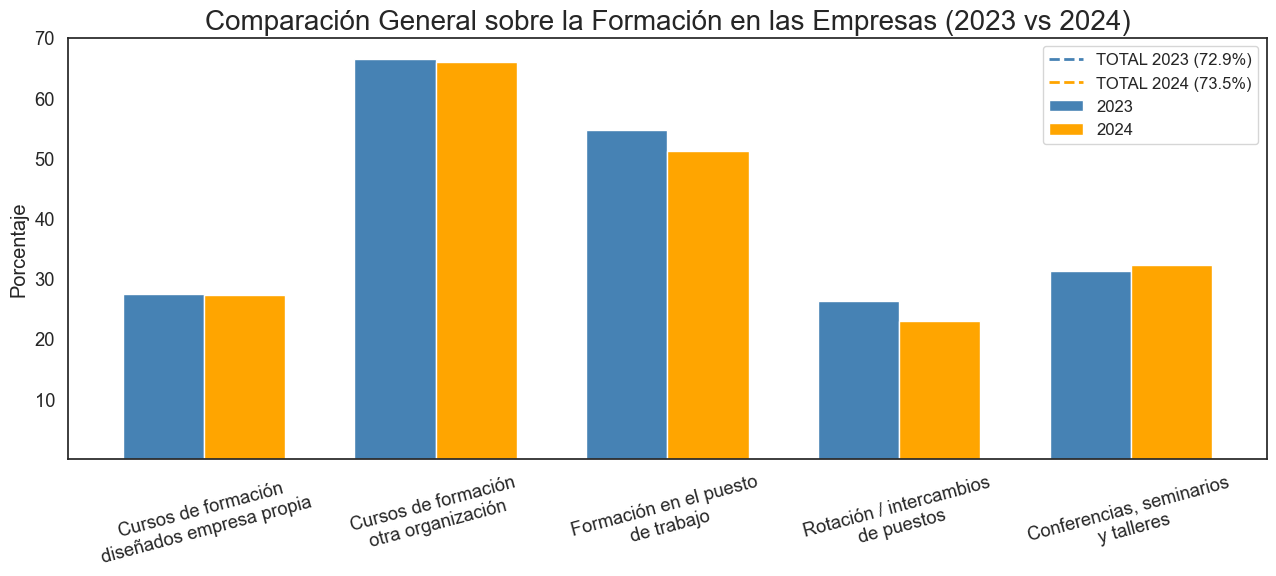

In [1692]:
# columnas de formación
categorias = [
    'Cursos de formación  diseñados y gestionados por su empresa',
    'Cursos de formación diseñados y gestionados por otra organización',
    'Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo',
    'Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.',
    'Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras'
]

# etiquetas cortas
new_labels = [
    'Cursos de formación\ndiseñados empresa propia',
    'Cursos de formación\notra organización',
    'Formación en el puesto\nde trabajo',
    'Rotación / intercambios\nde puestos',
    'Conferencias, seminarios\ny talleres'
]

# valores barras
val_2023 = df2023_tamano.iloc[0][categorias].values
val_2024 = df2024_tamano.iloc[0][categorias].values

# valores TOTAL para líneas
total_2023 = df2023_total.iloc[0]['TOTAL (2)']
total_2024 = df2024_total.iloc[0]['TOTAL']

# posiciones
x = np.arange(len(new_labels))
width = 0.35

# gráfico
plt.figure(figsize=(13,6))

# barras
plt.bar(x - width/2, val_2023, width, label='2023', color='steelblue')
plt.bar(x + width/2, val_2024, width, label='2024', color='orange')

# líneas discontinuas TOTAL
plt.axhline(
    y=total_2023,
    color='steelblue',
    linestyle='--',
    linewidth=2,
    label=f'TOTAL 2023 ({total_2023:.1f}%)'
)

plt.axhline(
    y=total_2024,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'TOTAL 2024 ({total_2024:.1f}%)'
)

# formato
plt.xticks(x, new_labels, rotation=15)
plt.yticks(np.arange(10, 101, 10))
plt.ylabel('Porcentaje')
plt.title('Comparación General sobre la Formación en las Empresas (2023 vs 2024)', fontsize=20)
plt.ylim(0, 70)

# leyenda
plt.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

In [1673]:
df2023_tamano.head()

,categoria,TOTAL (2),Cursos de formación diseñados y gestionados por su empresa,Cursos de formación diseñados y gestionados por otra organización,"Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo","Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.","Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras",bloque,año
4,De 5 a 9 trabajadores,64.670730,27.452634,66.497141,54.595202,26.269467,31.311321,tamaño_empresa,2023
5,De 10 a 49 trabajadores,79.013394,33.328382,74.868712,59.676870,25.119929,32.658179,tamaño_empresa,2023
6,De 50 a 249 trabajadores,94.064516,58.117774,85.302763,69.111307,36.576524,51.009210,tamaño_empresa,2023
7,De 250 a 499 trabajadores,98.313930,77.133524,84.646795,76.929359,42.017150,60.963659,tamaño_empresa,2023
8,Más de 499 trabajadores,99.188641,85.889571,85.071575,82.361963,50.869121,66.002045,tamaño_empresa,2023


In [1674]:
df2024_tamano.head()

,categoria,TOTAL,Cursos de formación diseñados y gestionados por su empresa,Cursos de formación diseñados y gestionados por otra organización,"Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo","Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.","Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras",bloque,año
4,De 5 a 9 trabajadores,65.319423,27.217848,65.989117,51.141371,22.937813,32.188656,tamaño_empresa,2024
5,De 10 a 49 trabajadores,79.227905,35.028637,79.002872,57.331022,29.277350,33.998708,tamaño_empresa,2024
6,De 50 a 249 trabajadores,94.759353,58.777973,84.135506,70.508861,36.475507,51.399249,tamaño_empresa,2024
7,De 250 a 499 trabajadores,98.385236,76.162564,85.384916,76.865963,46.697929,57.796014,tamaño_empresa,2024
8,Más de 499 trabajadores,99.275362,85.450122,84.963504,80.048662,51.532847,65.596107,tamaño_empresa,2024


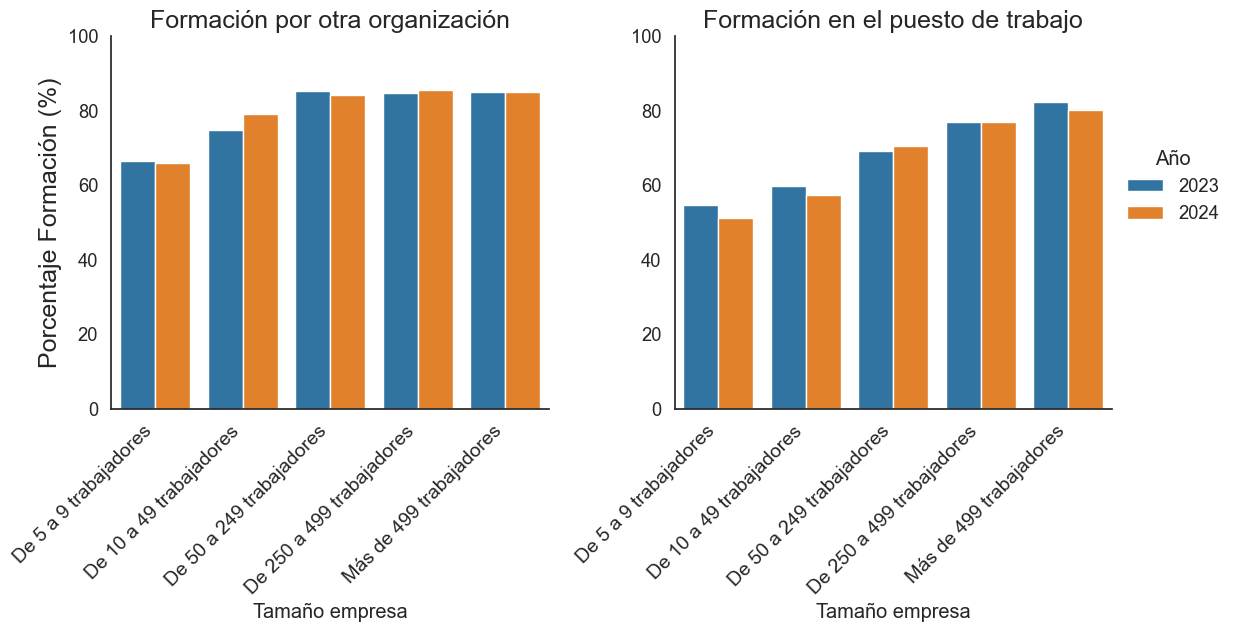

In [1675]:
# ----------------------------
# 1. Unir datos
# ----------------------------
df2023_tamano = df2023_tamano.copy()
df2024_tamano = df2024_tamano.copy()

df2023_tamano['año'] = 2023
df2024_tamano['año'] = 2024

df_tamano = pd.concat([df2023_tamano, df2024_tamano], ignore_index=True)

# ----------------------------
# 2. Melt
# ----------------------------
df_long = df_tamano.melt(
    id_vars=['categoria', 'bloque', 'año'],
    value_vars=[
        'Cursos de formación diseñados y gestionados por otra organización',
        'Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo',
    ],
    var_name='tipo_formacion',
    value_name='porcentaje'
)

# ----------------------------
# 3. ORDEN FIJO DEL EJE X
# ----------------------------
orden = [
    'De 5 a 9 trabajadores',
    'De 10 a 49 trabajadores',
    'De 50 a 249 trabajadores',
    'De 250 a 499 trabajadores',
    'Más de 499 trabajadores'
]

df_long['categoria'] = pd.Categorical(
    df_long['categoria'],
    categories=orden,
    ordered=True
)

# ----------------------------
# 4. Nombres más cortos
# ----------------------------
mapa_nombres = {
    'Cursos de formación diseñados y gestionados por otra organización': 'Formación por otra organización',
    'Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo': 'Formación en el puesto de trabajo'
}

df_long['tipo_formacion'] = df_long['tipo_formacion'].replace(mapa_nombres)

# ----------------------------
# 5. Orden y colores del hue
# ----------------------------
df_long['año'] = pd.Categorical(
    df_long['año'],
    categories=[2023, 2024],
    ordered=True
)

palette = {
    2023: "tab:blue",
    2024: "tab:orange"
}

# ----------------------------
# 6. GRÁFICO
# ----------------------------
g = sns.catplot(
    data=df_long,
    x='categoria',
    y='porcentaje',
    hue='año',
    col='tipo_formacion',
    kind='bar',
    col_wrap=2,
    height=5,
    aspect=1.1,
    sharey=False,
    palette=palette
)

# Títulos
g.set_titles("{col_name}", size=18)

# Leyenda arriba
sns.move_legend(
    g,
    "center left",
    bbox_to_anchor=(0.9, 0.6),
    ncol=1,
    title="Año",
    frameon=False
)

# ----------------------------
# 7. AJUSTES VISUALES
# ----------------------------
for ax in g.axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("Porcentaje", fontsize=18)
    ax.set_ylim(0, 100)

    ax.set_xticks(range(len(orden)))
    ax.set_xticklabels(orden, rotation=45, ha='right', fontsize=14)
    ax.tick_params(axis='x', labelsize=14)

g.set_axis_labels("Tamaño empresa", "Porcentaje Formación (%)")

plt.subplots_adjust(top=0.90)
plt.show()

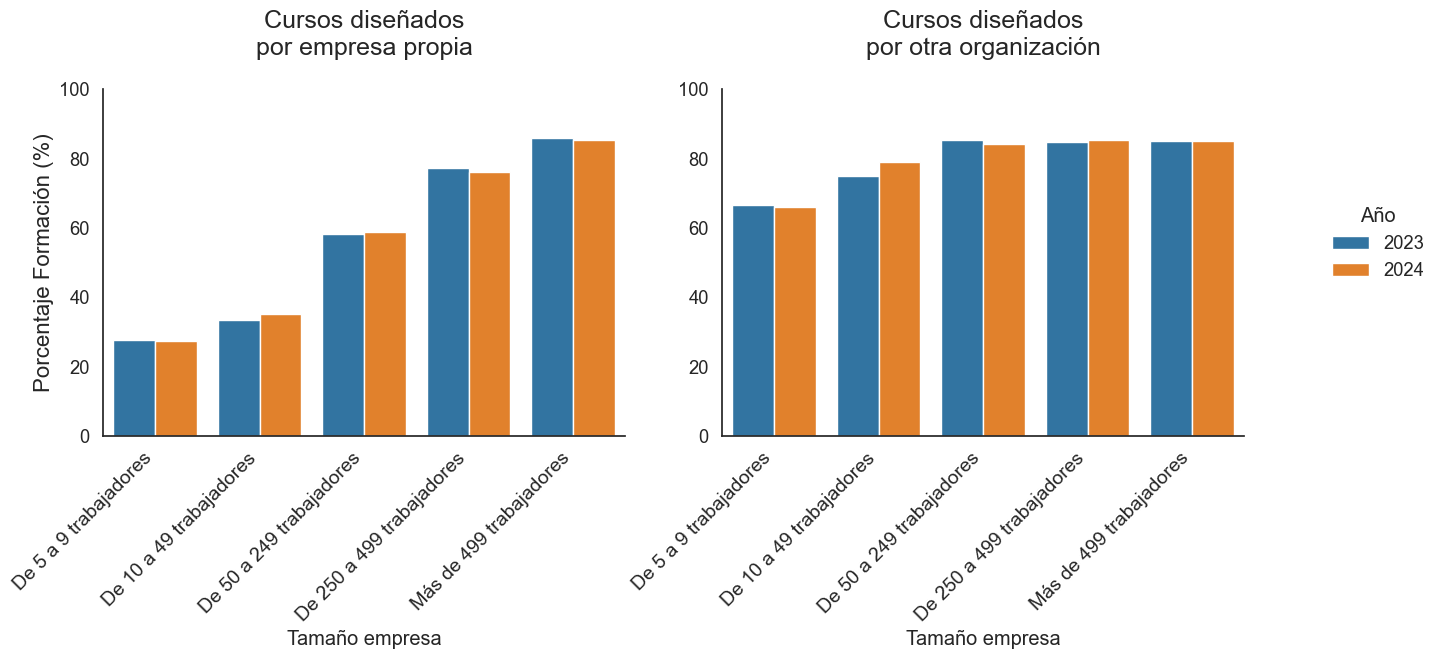

In [1676]:
# ----------------------------
# 1. Unir datos
# ----------------------------
df2023_tamano = df2023_tamano.copy()
df2024_tamano = df2024_tamano.copy()

df2023_tamano['año'] = 2023
df2024_tamano['año'] = 2024

df_tamano = pd.concat([df2023_tamano, df2024_tamano], ignore_index=True)

# ----------------------------
# 2. Melt
# ----------------------------
df_long = df_tamano.melt(
    id_vars=['categoria', 'bloque', 'año'],
    value_vars=[
        'Cursos de formación  diseñados y gestionados por su empresa',
        'Cursos de formación diseñados y gestionados por otra organización'
    ],
    var_name='tipo_formacion',
    value_name='porcentaje'
)

# ----------------------------
# 3. ORDEN FIJO DEL EJE X
# ----------------------------
orden = [
    'De 5 a 9 trabajadores',
    'De 10 a 49 trabajadores',
    'De 50 a 249 trabajadores',
    'De 250 a 499 trabajadores',
    'Más de 499 trabajadores'
]

df_long['categoria'] = pd.Categorical(
    df_long['categoria'],
    categories=orden,
    ordered=True
)

# ----------------------------
# 4. Nombres más cortos + salto de línea (clave para legibilidad)
# ----------------------------
mapa_nombres = {
    'Cursos de formación  diseñados y gestionados por su empresa':
        'Cursos diseñados\npor empresa propia',
    'Cursos de formación diseñados y gestionados por otra organización':
        'Cursos diseñados\npor otra organización',
}

df_long['tipo_formacion'] = df_long['tipo_formacion'].map(mapa_nombres)

# ----------------------------
# 5. ORDEN Y COLORES DEL AÑO
# ----------------------------
df_long['año'] = pd.Categorical(
    df_long['año'],
    categories=[2023, 2024],
    ordered=True
)

palette = {
    2023: "tab:blue",
    2024: "tab:orange"
}

# ----------------------------
# 6. GRÁFICO
# ----------------------------
g = sns.catplot(
    data=df_long,
    x='categoria',
    y='porcentaje',
    hue='año',
    col='tipo_formacion',
    kind='bar',
    col_wrap=2,
    height=5.5,
    aspect=1.2,
    sharey=False,
    palette=palette
)

# ----------------------------
# 7. TÍTULOS MÁS ESPACIADOS (IMPORTANTE)
# ----------------------------
g.set_titles("{col_name}", size=18, pad=25)

# ----------------------------
# 8. LEYENDA
# ----------------------------
sns.move_legend(
    g,
    "center left",
    bbox_to_anchor=(0.9, 0.6),
    ncol=1,
    title="Año",
    frameon=False
)

# ----------------------------
# 9. AJUSTES VISUALES
# ----------------------------
for ax in g.axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("Porcentaje", fontsize=16)
    ax.set_ylim(0, 100)

    ax.set_xticks(range(len(orden)))
    ax.set_xticklabels(orden, rotation=45, ha='right', fontsize=14)
    ax.tick_params(axis='x', labelsize=14)

# Etiquetas globales
g.set_axis_labels("Tamaño empresa", "Porcentaje Formación (%)")

# ----------------------------
# 10. LAYOUT FINAL (sin conflictos)
# ----------------------------
g.fig.subplots_adjust(bottom=0.25, top=0.88, left=0.05, right=0.85)


plt.show()

In [1677]:
df2023_actividad.head(10)

,categoria,TOTAL (2),Cursos de formación diseñados y gestionados por su empresa,Cursos de formación diseñados y gestionados por otra organización,"Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo","Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.","Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras",bloque,año
11,Industria,78.356762,35.335511,72.393006,61.640809,33.150007,30.577838,actividad,2023
12,Construcción,79.310809,25.605654,78.549823,63.259364,22.894700,21.925088,actividad,2023
13,Comercio y reparación de vehículos,70.702769,34.418410,72.647356,58.602862,28.884518,40.046304,actividad,2023
14,Transporte y almacenamiento,79.535758,29.931669,78.440513,53.049365,20.154544,17.306341,actividad,2023
15,Hostelería,58.387782,23.458918,63.714466,58.234151,24.857041,17.404033,actividad,2023
16,"Información, comunicaciones, actividades finan...",81.274725,47.985398,69.172526,56.429151,29.583559,54.286101,actividad,2023
17,"Actividades profesionales, científicas y técnicas",82.792534,44.897408,73.321634,56.029518,24.586033,61.258099,actividad,2023
18,Actividades administrativas y servicios auxili...,72.705540,36.890636,76.654753,56.933524,25.153681,34.381701,actividad,2023
19,"Actividades artísticas, recreativas y de entre...",71.846197,37.501620,65.135415,51.768822,26.247246,46.650253,actividad,2023


In [1678]:
df2024_actividad.head(10)

,categoria,TOTAL,Cursos de formación diseñados y gestionados por su empresa,Cursos de formación diseñados y gestionados por otra organización,"Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo","Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.","Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras",bloque,año
11,Industria,76.222600,34.293577,76.121179,61.910901,36.081017,33.867169,actividad,2024
12,Construcción,77.712290,22.420652,84.768610,57.771672,21.273003,23.030251,actividad,2024
13,Comercio y reparación de vehículos,73.958727,38.680615,71.445779,54.400700,29.940268,41.624315,actividad,2024
14,Transporte y almacenamiento,77.406769,30.568829,79.668783,52.052104,24.258690,20.416312,actividad,2024
15,Hostelería,60.735371,25.970788,68.136490,54.371695,21.531100,13.127676,actividad,2024
16,"Información, comunicaciones, actividades finan...",80.544101,48.577128,73.397606,52.972074,31.788564,63.623670,actividad,2024
17,"Actividades profesionales, científicas y técnicas",81.788176,42.449776,68.304581,51.031088,25.282718,59.222138,actividad,2024
18,Actividades administrativas y servicios auxili...,74.261496,36.374821,74.834256,60.200943,28.282414,39.518830,actividad,2024
19,"Actividades artísticas, recreativas y de entre...",73.507801,40.519529,67.162337,57.172827,24.520269,43.228235,actividad,2024


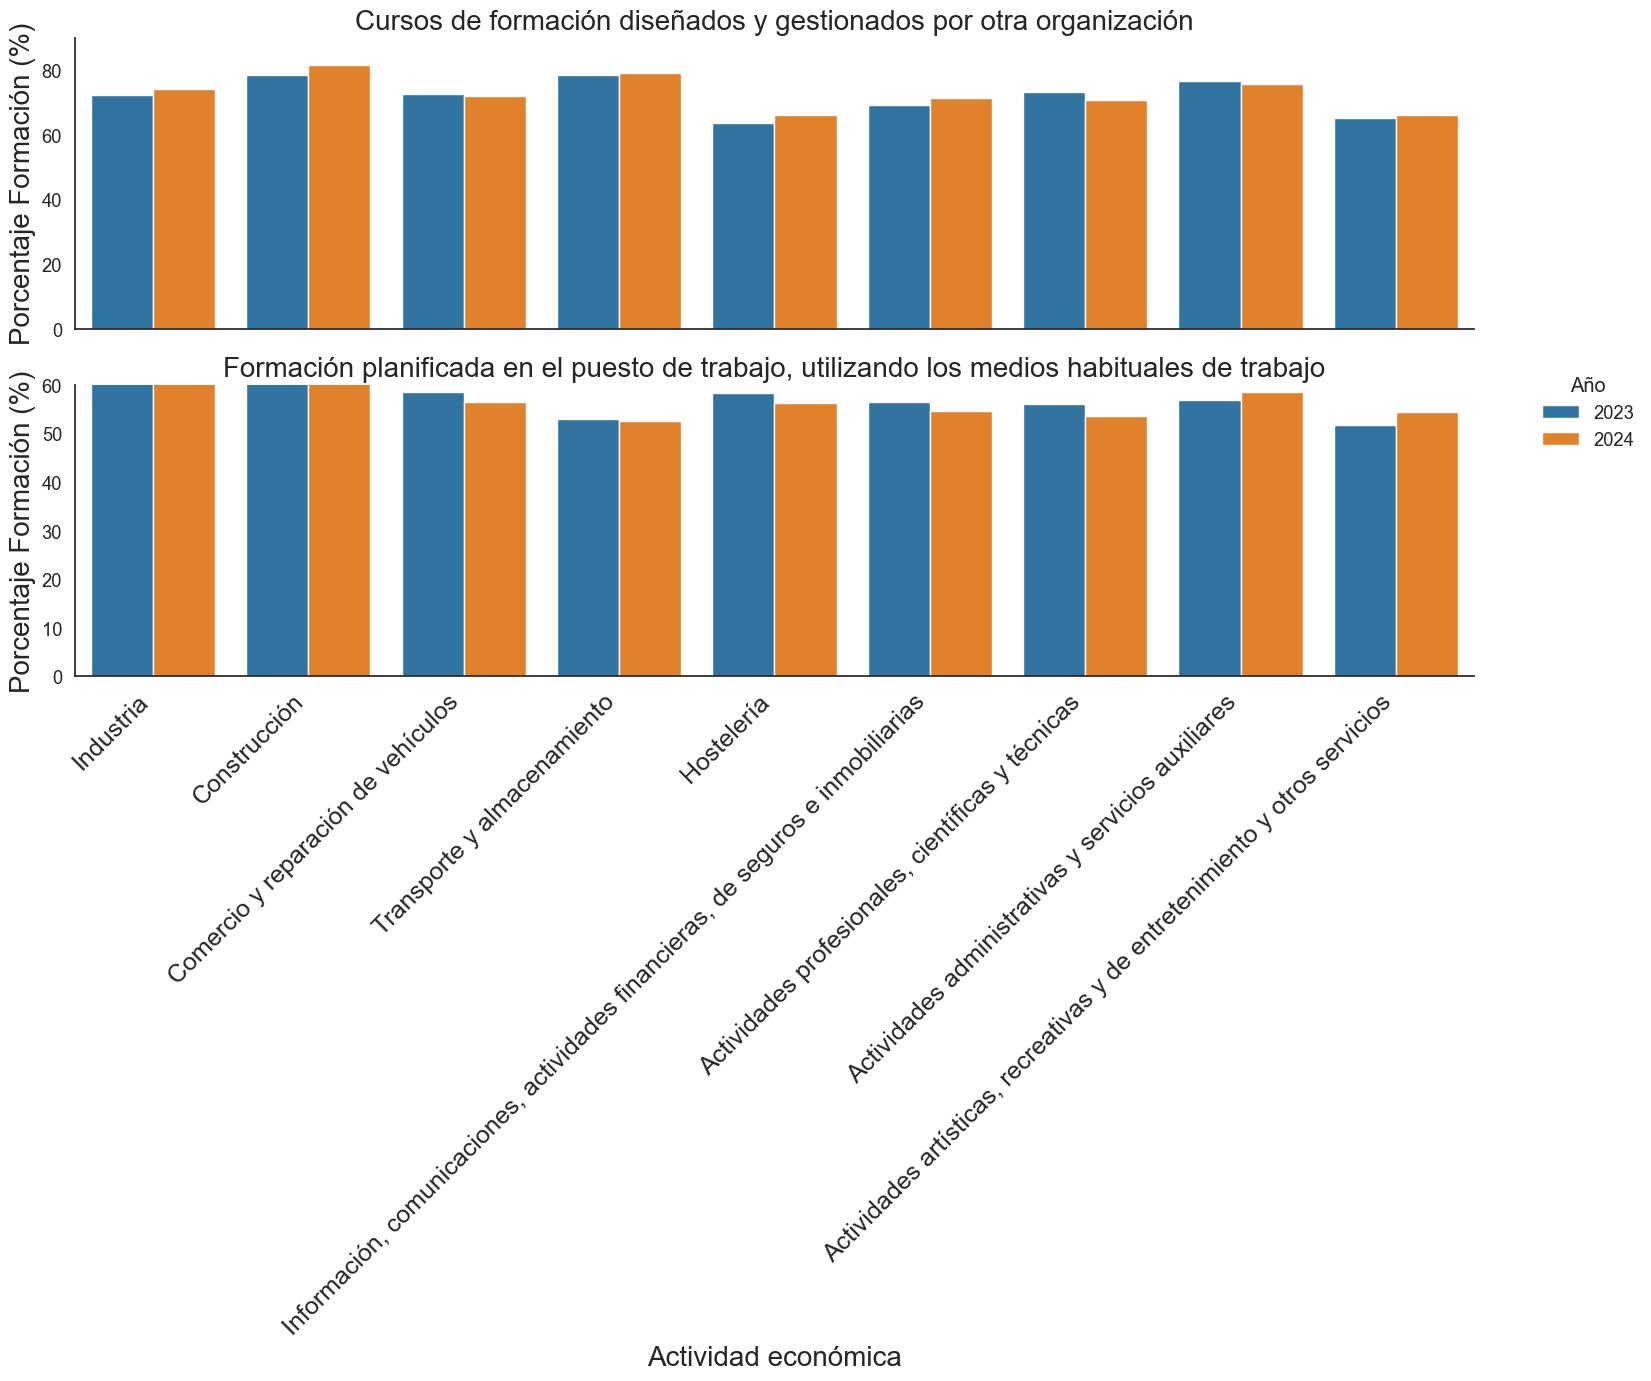

In [1708]:
# ----------------------------
# 1. Unir datos
# ----------------------------
df2023_actividad = df2023_actividad.copy()
df2024_actividad = df2024_actividad.copy()

df2023_actividad['año'] = 2023
df2024_actividad['año'] = 2024

df_actividad = pd.concat([df2023_actividad, df2024_actividad], ignore_index=True)

# ----------------------------
# 2. Melt
# ----------------------------
df_long = df_actividad.melt(
    id_vars=['categoria', 'bloque', 'año'],
    value_vars=[
        'Cursos de formación diseñados y gestionados por otra organización',
        'Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo',
    ],
    var_name='tipo_formacion',
    value_name='porcentaje'
)
orden = [
    'Industria',
    'Construcción',
    'Comercio y reparación de vehículos',
    'Transporte y almacenamiento',
    'Hostelería',
    'Información, comunicaciones, actividades financieras, de seguros e inmobiliarias',
    'Actividades profesionales, científicas y técnicas',
    'Actividades administrativas y servicios auxiliares',
    'Actividades artísticas, recreativas y de entretenimiento y otros servicios',
]

df_long['categoria'] = pd.Categorical(
    df_long['categoria'],
    categories=orden,
    ordered=True
)

# ----------------------------
# 4. Nombres más cortos
# ----------------------------
mapa_nombres = {
    'Cursos de formación diseñados y gestionados por otra organización': 'Formación por otra organización',
    'Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo': 'Formación en el puesto de trabajo'
}

# ----------------------------
# 5. Fijar orden y colores del hue
# ----------------------------
df_long['año'] = pd.Categorical(
    df_long['año'],
    categories=[2023, 2024],
    ordered=True
)

palette = {
    2023: "tab:blue",
    2024: "tab:orange"
}

# ----------------------------
# 6. Gráfico
# ----------------------------
g = sns.catplot(
    data=df_long,
    x='categoria',
    y='porcentaje',
    hue='año',
    col='tipo_formacion',
    kind='bar',
    col_wrap=1,
    height=7,
    aspect=2,
    sharey=False,
    palette=palette,
    errorbar=None
)

# Títulos limpios
g.set_titles("{col_name}")

# Leyenda
sns.move_legend(
    g,
    "center left",
    bbox_to_anchor=(1.02, 0.7),
    ncol=1,
    title="Año",
    frameon=False
)

# ----------------------------
# 7. Ajustes visuales + etiquetas
# ----------------------------
for i, ax in enumerate(g.axes.flat):

    ax.set_xlabel("")
    ax.set_ylabel("Porcentaje", fontsize=18)

    ax.set_xticks(range(len(orden)))
    ax.set_xticklabels(orden, rotation=45, ha='right', fontsize=18)
    

    # límites por subplot
    if i == 0:
        ax.set_ylim(0, 90)
    elif i == 1:
        ax.set_ylim(0, 60)

  

g.set_axis_labels("Actividad económica", "Porcentaje Formación (%)",fontsize=20)


plt.subplots_adjust(bottom=0.25, top=0.88)


plt.tight_layout()
g.set_titles("{col_name}", size=20)
plt.show()

In [1680]:
df2023_ccaa.head(20)

,categoria,TOTAL (2),Cursos de formación diseñados y gestionados por su empresa,Cursos de formación diseñados y gestionados por otra organización,"Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo","Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.","Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras",bloque,año
22,Andalucía,73.308284,26.799510,73.865540,55.196640,24.941871,28.039603,ccaa,2023
23,Aragón,78.902352,31.875081,73.132017,58.833398,29.190863,33.926958,ccaa,2023
24,Asturias (Principado de),74.890653,30.737616,71.620160,51.719663,18.689163,30.607830,ccaa,2023
25,Balears (Illes),67.030587,36.236371,65.203931,63.494414,31.578947,34.688383,ccaa,2023
26,Canarias,62.514076,35.807736,77.133106,56.958665,26.241942,28.981797,ccaa,2023
27,Cantabria,76.731657,31.795386,75.459712,58.609161,19.859579,26.847208,ccaa,2023
28,Castilla-La Mancha,69.834357,32.305122,73.619154,59.922049,22.672606,28.118040,ccaa,2023
29,Castilla y León,74.853918,31.775038,71.782134,56.994589,27.179988,27.650137,ccaa,2023
30,Cataluña,74.478543,35.726954,71.752939,59.729841,26.984945,40.831099,ccaa,2023
31,Comunitat Valenciana,72.760795,29.908077,67.690748,60.557128,28.964384,32.155465,ccaa,2023


In [1681]:
df2024_ccaa.head(20)


,categoria,TOTAL,Cursos de formación diseñados y gestionados por su empresa,Cursos de formación diseñados y gestionados por otra organización,"Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo","Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.","Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras",bloque,año
22,Andalucía,73.324726,23.902570,76.823751,47.927417,26.162236,27.756719,ccaa,2024
23,Aragón,73.587186,36.262834,73.538672,54.976044,25.530459,38.644764,ccaa,2024
24,Asturias (Principado de),73.013871,32.340242,74.395509,57.966321,21.200345,32.102763,ccaa,2024
25,Balears (Illes),61.535068,30.394265,72.688172,55.641577,23.412186,36.071685,ccaa,2024
26,Canarias,69.624593,29.797179,71.321259,59.961606,24.021367,28.428345,ccaa,2024
27,Cantabria,71.580278,36.700812,78.205581,53.973861,27.446132,31.755563,ccaa,2024
28,Castilla-La Mancha,73.929811,29.233177,76.306729,55.336463,27.470005,36.765780,ccaa,2024
29,Castilla y León,70.565964,35.078631,70.767808,50.712303,26.938020,36.956522,ccaa,2024
30,Cataluña,76.295600,37.301272,75.365660,58.316773,30.781002,41.250000,ccaa,2024
31,Comunitat Valenciana,74.320098,38.074398,71.119340,55.536105,26.032654,32.280761,ccaa,2024


In [1684]:
print(df2024_ccaa.columns.tolist())

['categoria', 'TOTAL', 'Cursos de formación  diseñados y gestionados por su empresa', 'Cursos de formación diseñados y gestionados por otra organización', 'Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo', 'Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.', 'Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras', 'bloque', 'año']


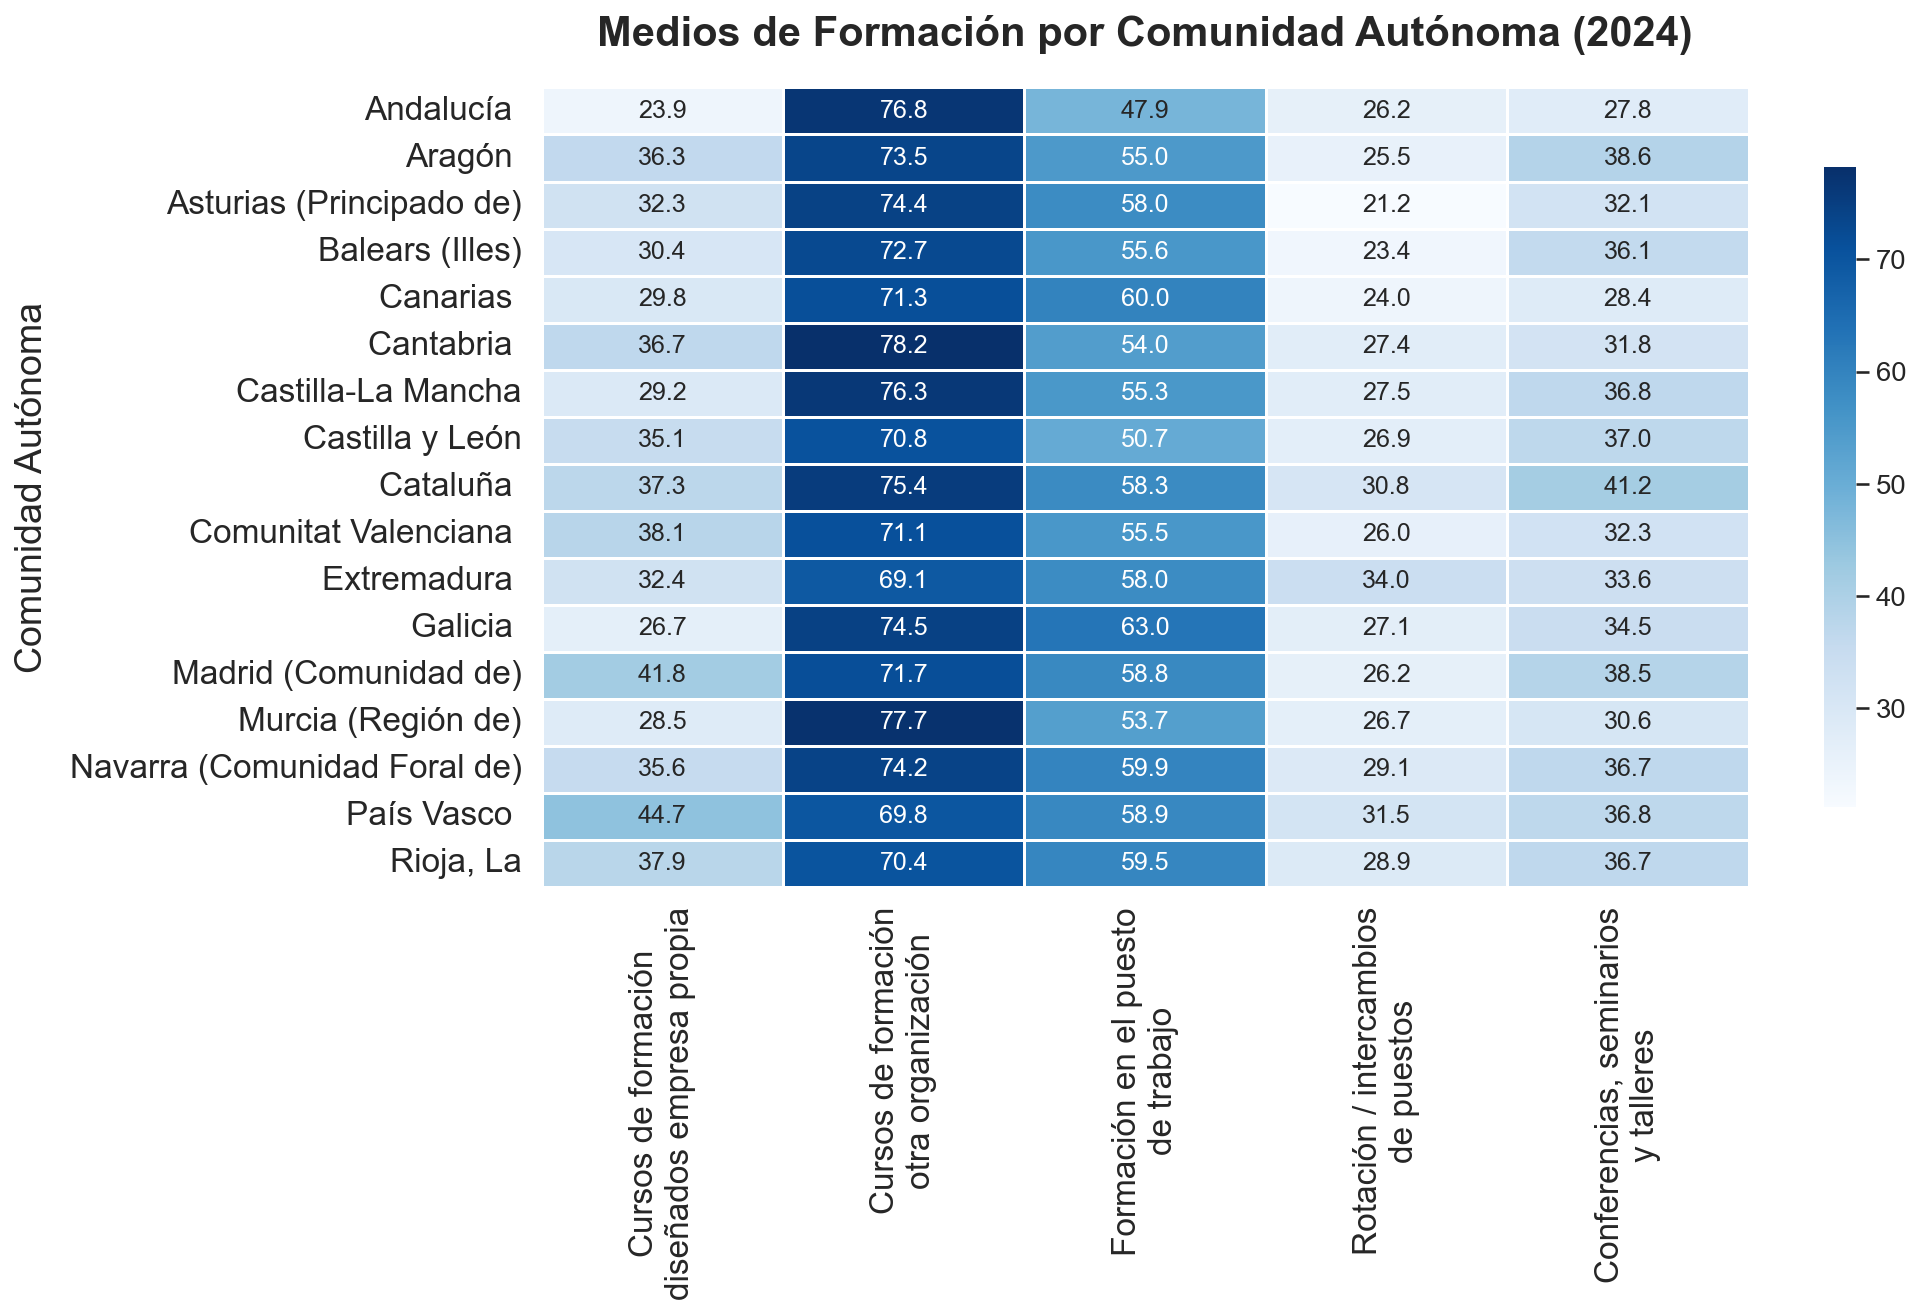

In [1701]:
sns.set_theme(style="white", font_scale=1.2)

# Renombrar columnas con saltos de línea (más legible)
df_heat = df2024_ccaa.set_index("categoria")[
    [
        'Cursos de formación  diseñados y gestionados por su empresa',
        'Cursos de formación diseñados y gestionados por otra organización',
        'Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo',
        'Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.',
        'Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras'
    ]
]

new_labels = [
    'Cursos de formación\ndiseñados empresa propia',
    'Cursos de formación\notra organización',
    'Formación en el puesto\nde trabajo',
    'Rotación / intercambios\nde puestos',
    'Conferencias, seminarios\ny talleres'
]

plt.figure(figsize=(14, 9), dpi=150)

ax = sns.heatmap(
    df_heat,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)

# Título con jerarquía clara
plt.title(
    "Medios de Formación por Comunidad Autónoma (2024)",
    fontsize=20,
    weight="bold",
    pad=20
)

# Ejes
plt.ylabel("Comunidad Autónoma", fontsize=18, labelpad=10)
plt.xlabel("")

# Etiquetas eje X (2 líneas + legibles)
ax.set_xticklabels(new_labels, rotation=90, fontsize=16, ha="center")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)

# Mejorar legibilidad de números
for text in ax.texts:
    text.set_fontsize(12)

plt.tight_layout()
plt.show()

C:\Users\NURIA\AppData\Local\Temp\ipykernel_13416\1517923636.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_sign = df_sign.applymap(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))


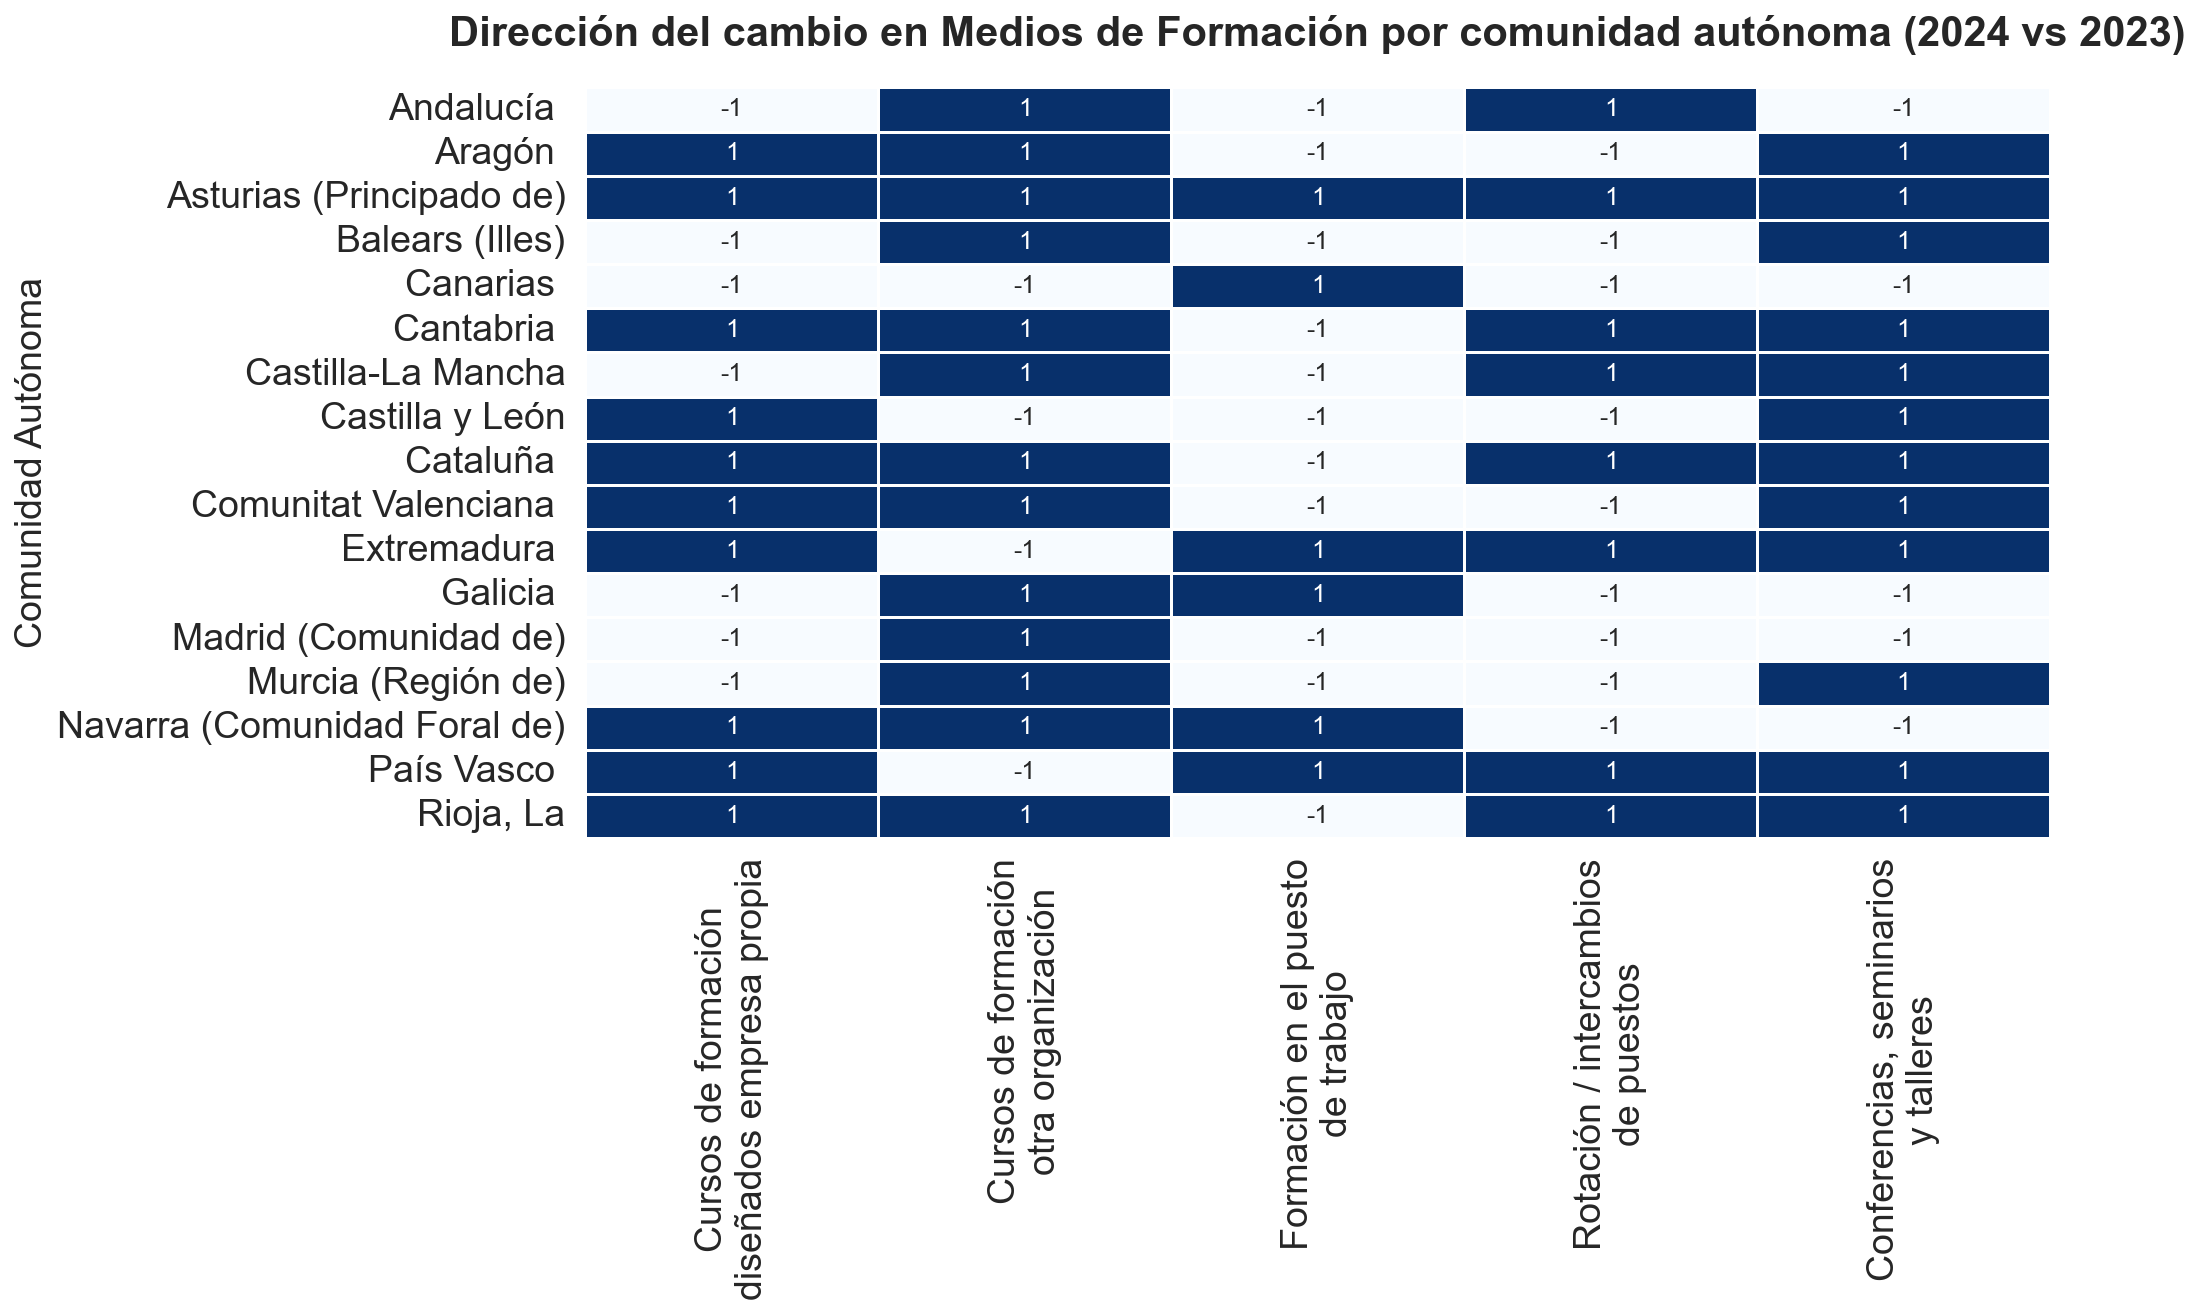

In [1686]:
cols = [
    'Cursos de formación  diseñados y gestionados por su empresa',
    'Cursos de formación diseñados y gestionados por otra organización',
    'Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo',
    'Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.',
    'Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras'
]

df_23 = df2023_ccaa.set_index("categoria")[cols]
df_24 = df2024_ccaa.set_index("categoria")[cols]

df_diff = df_24 - df_23

df_sign = df_diff.copy()

df_sign = df_sign.applymap(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
# Ahora df_sign tiene 1 para aumentos, -1 para disminuciones y 0 para sin cambio

new_labels = [
    'Cursos de formación\ndiseñados empresa propia',
    'Cursos de formación\notra organización',
    'Formación en el puesto\nde trabajo',
    'Rotación / intercambios\nde puestos',
    'Conferencias, seminarios\ny talleres'
]

sns.set_theme(style="white", font_scale=1.2)

plt.figure(figsize=(14, 9), dpi=150)

ax = sns.heatmap(
    df_sign,
    cmap="Blues",
    center=0,
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor="white",
    cbar=False,
    annot_kws={"size": 12}   # 👈 tamaño de los números
)

plt.title(
    "Dirección del cambio en Medios de Formación por comunidad autónoma (2024 vs 2023)",
    fontsize=20,
    weight="bold",
    pad=20
)

plt.ylabel("Comunidad Autónoma", fontsize=18)
plt.xlabel("")

ax.set_xticklabels(new_labels, rotation=90, fontsize=18, ha="center")

plt.yticks(fontsize=18)

plt.tight_layout()
plt.show()

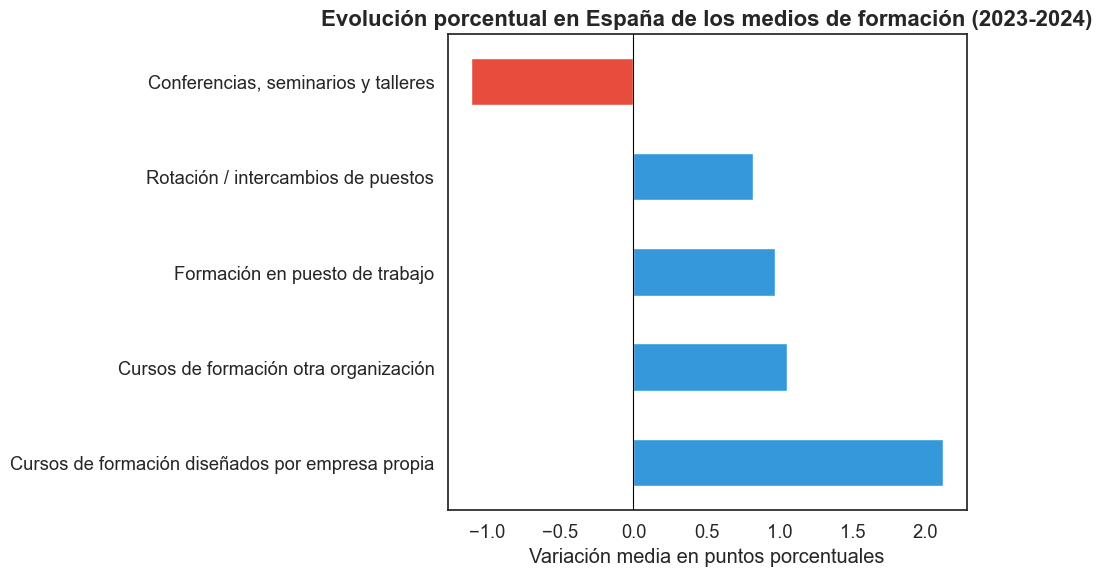

In [1702]:
cols = [
    'Cursos de formación  diseñados y gestionados por su empresa',
    'Cursos de formación diseñados y gestionados por otra organización',
    'Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo',
    'Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.',
    'Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras'
]
# diferencias entre 2024 y 2023 por comunidad autónoma
df_23 = df2023_ccaa.set_index("categoria")[cols]
df_24 = df2024_ccaa.set_index("categoria")[cols]
# diferencia absoluta entre 2024 y 2023 por comunidad autónoma
df_diff = df_24 - df_23

# variaciones medias entre 2024 y 2023 por cada tipo de formación
variacion_media = df_diff.mean().sort_values(ascending=False)

# etiquetas más legibles
variacion_media.index = [
    'Cursos de formación diseñados por empresa propia',
    'Cursos de formación otra organización',
    'Formación en puesto de trabajo',
    'Rotación / intercambios de puestos',
    'Conferencias, seminarios y talleres'
]
# gráfico

colors = ['#3498db' if x > 0 else '#e74c3c' for x in variacion_media]

plt.figure(figsize=(10,6))

variacion_media.plot(
    kind='barh',
    color=colors
)

plt.title(
    'Evolución porcentual en España de los medios de formación (2023-2024)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Variación media en puntos porcentuales')
plt.ylabel('')

plt.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


C:\Users\NURIA\AppData\Local\Temp\ipykernel_13416\1059533325.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_signt_t = df_signt_t.applymap(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))


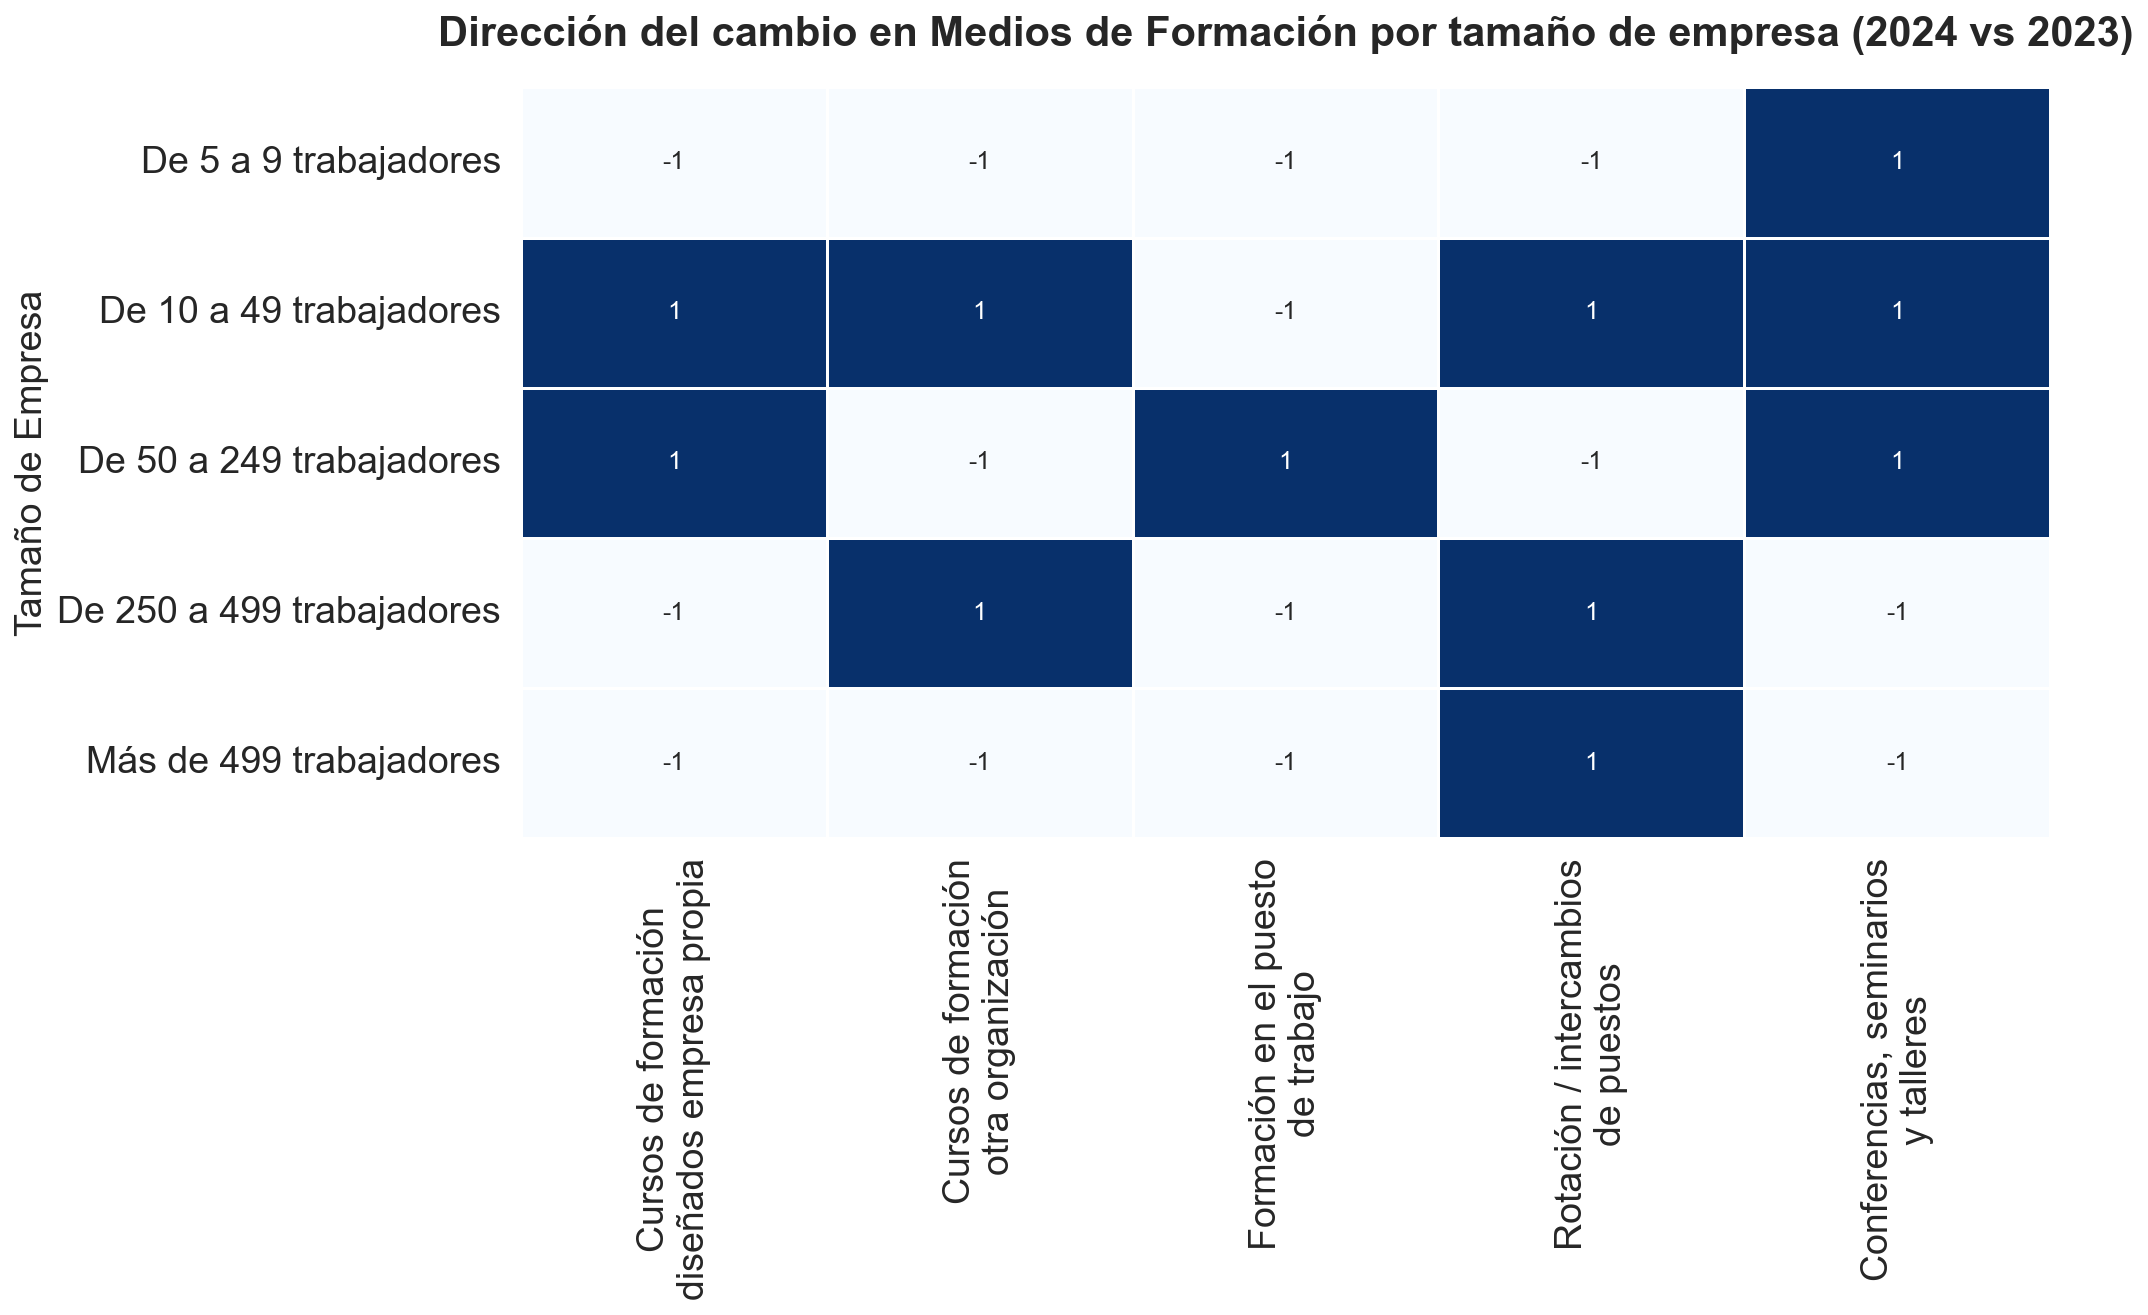

In [1688]:
cols = [
    'Cursos de formación  diseñados y gestionados por su empresa',
    'Cursos de formación diseñados y gestionados por otra organización',
    'Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo',
    'Aprendizaje planificado a partir de rotación de puestos de trabajo, intercambios, etc.',
    'Participación en conferencias, seminarios, grupos de trabajo, talleres o ferias de muestras'
]

df_23t = df2023_tamano.set_index("categoria")[cols]
df_24t = df2024_tamano.set_index("categoria")[cols]

df_diff_t = df_24t - df_23t
df_signt_t = df_diff_t.copy()
df_signt_t = df_signt_t.applymap(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
# Ahora df_signt_t tiene 1 para aumentos, -1 para disminuciones y 0 para sin cambio
new_labels = [
    'Cursos de formación\ndiseñados empresa propia',
    'Cursos de formación\notra organización',
    'Formación en el puesto\nde trabajo',
    'Rotación / intercambios\nde puestos',
    'Conferencias, seminarios\ny talleres'
]

sns.set_theme(style="white", font_scale=1.2)

plt.figure(figsize=(14, 9), dpi=150)

ax = sns.heatmap(
    df_signt_t,
    cmap="Blues",
    center=0,
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor="white",
    cbar=False,
    annot_kws={"size": 12}   # 👈 tamaño de los números
)

plt.title(
    "Dirección del cambio en Medios de Formación por tamaño de empresa (2024 vs 2023)",
    fontsize=20,
    weight="bold",
    pad=20
)

plt.ylabel("Tamaño de Empresa", fontsize=18)
plt.xlabel("")

ax.set_xticklabels(new_labels, rotation=90, fontsize=18, ha="center")

plt.yticks(fontsize=18)

plt.tight_layout()
plt.show()

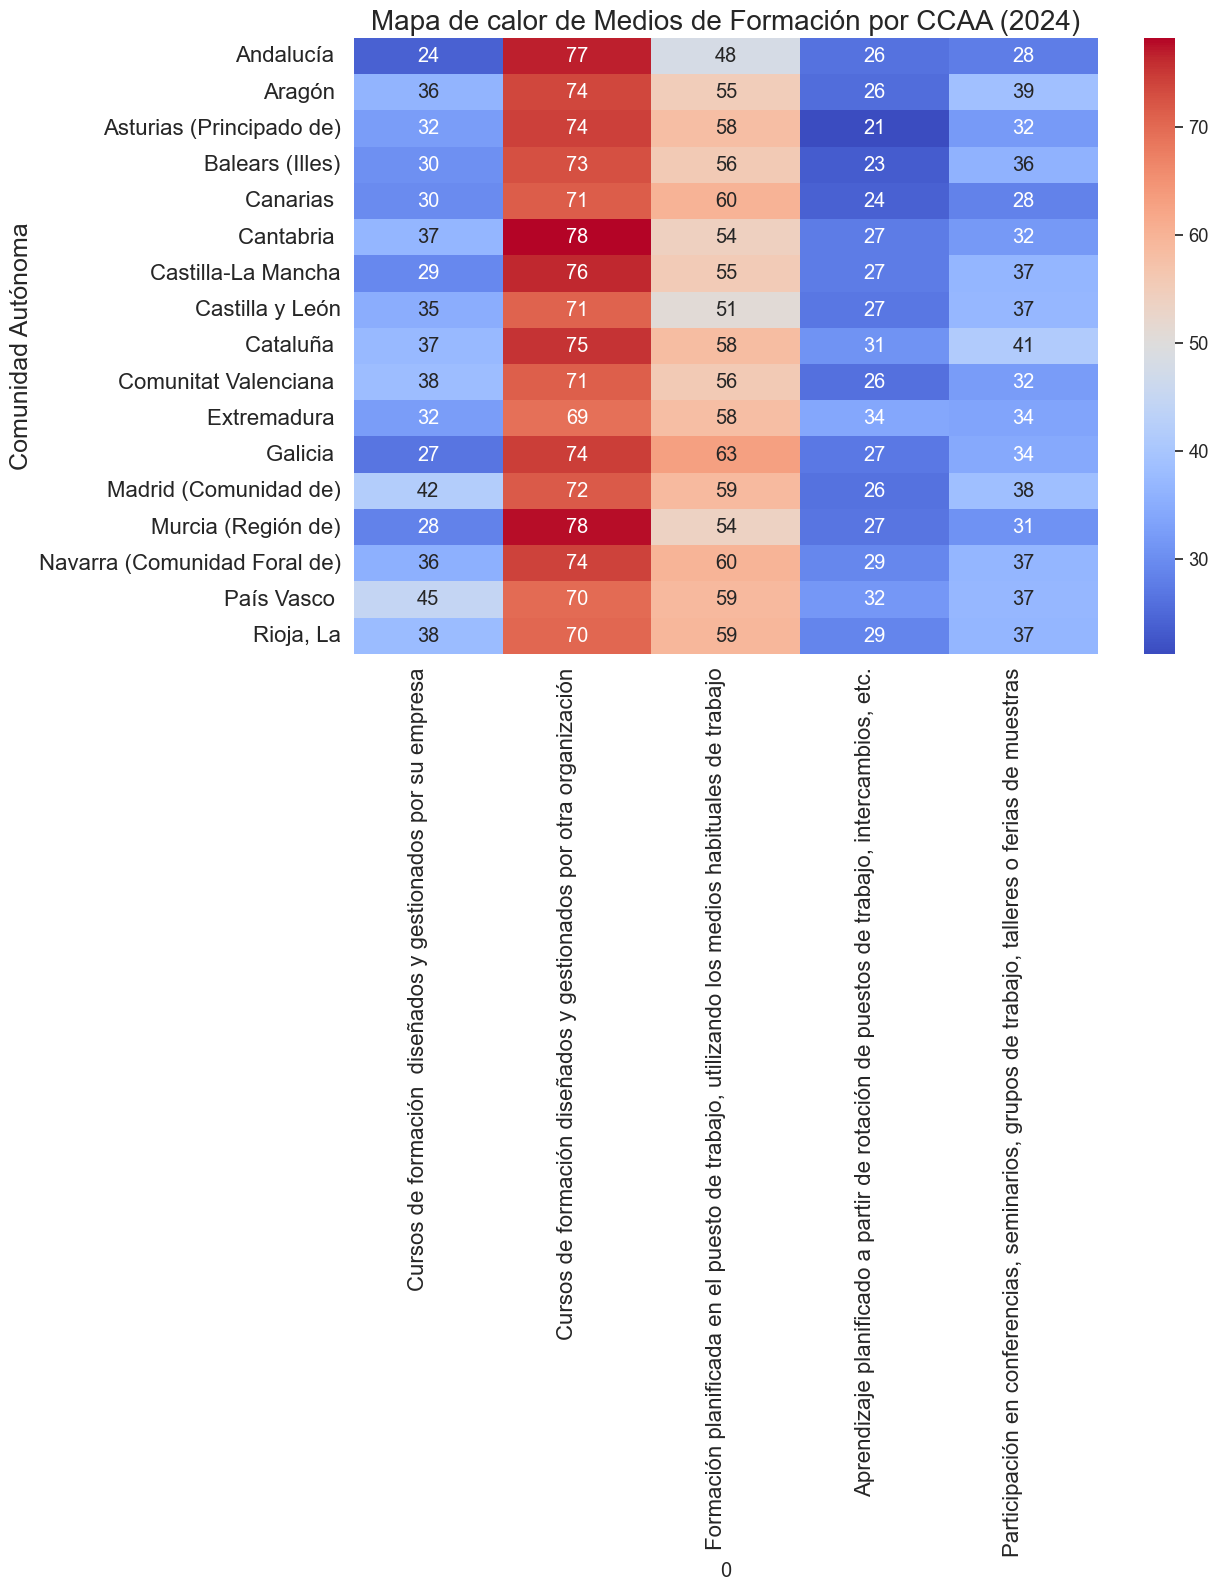

In [1690]:
new_labels = [
    'Cursos de formación\ndiseñados y gestionados por su empresa',
    'Cursos de formación\ndiseñados y gestionados por otra organización',
    'Formación planificada en el puesto\nde trabajo, utilizando los medios habituales',
    'Aprendizaje planificado a partir de rotación\nde puestos de trabajo, intercambios, etc.',
    'Participación en conferencias, seminarios,\ngrupos de trabajo, talleres o ferias de muestras'
]

plt.figure(figsize=(12,8))
sns.heatmap(df_heat, annot=True, cmap="coolwarm")

plt.title("Mapa de calor de Medios de Formación por CCAA (2024)",fontsize=20)
plt.ylabel("Comunidad Autónoma", fontsize=18)
plt.yticks(fontsize=16)
plt.xticks(rotation=90, ha='right', fontsize=16)
plt.show()

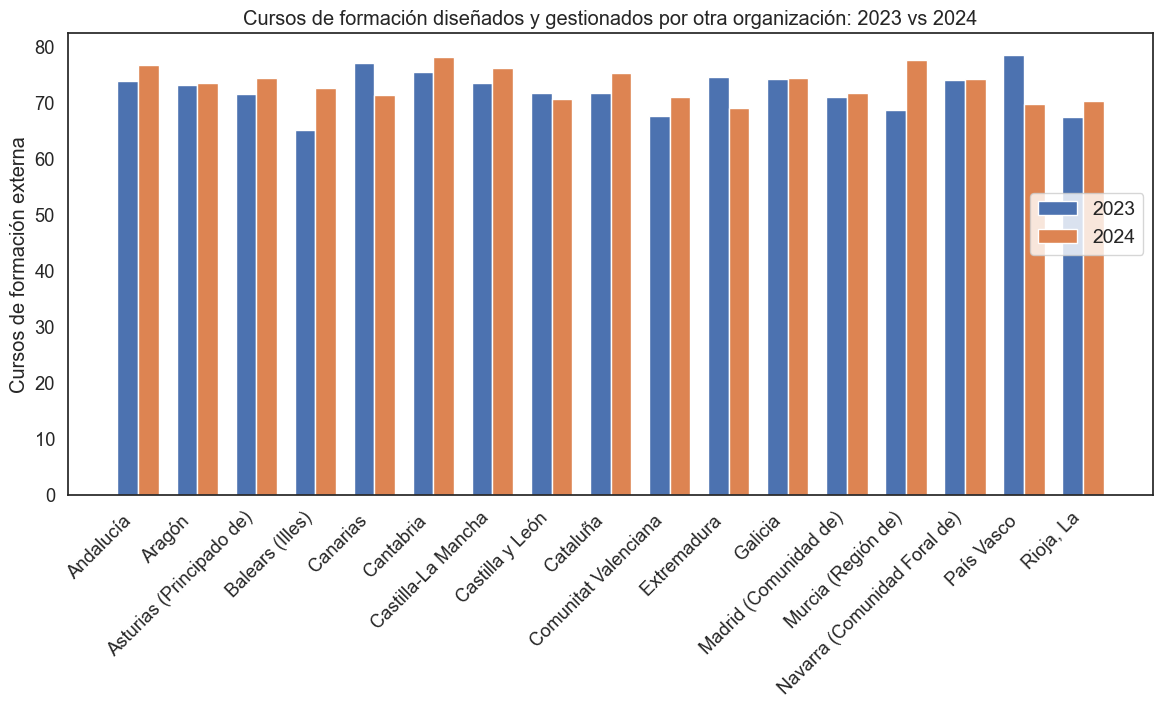

In [1703]:
# columna objetivo
col = 'Cursos de formación diseñados y gestionados por otra organización'

# filtrar por año y columna correcta
df_2023 = df2023_ccaa[df2023_ccaa['año'] == 2023][['categoria', col]].rename(columns={col: '2023'})
df_2024 = df2024_ccaa[df2024_ccaa['año'] == 2024][['categoria', col]].rename(columns={col: '2024'})

# merge
df_ccaa = pd.merge(df_2023, df_2024, on='categoria', how='inner')

# gráfico
x = np.arange(len(df_ccaa['categoria']))
width = 0.35

plt.figure(figsize=(14,6))

plt.bar(x - width/2, df_ccaa['2023'], width, label='2023')
plt.bar(x + width/2, df_ccaa['2024'], width, label='2024')

plt.xticks(x, df_ccaa['categoria'], rotation=45, ha='right')
plt.ylabel('Cursos de formación externa')
plt.title('Cursos de formación diseñados y gestionados por otra organización: 2023 vs 2024')
plt.legend(loc='lower right', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=14)

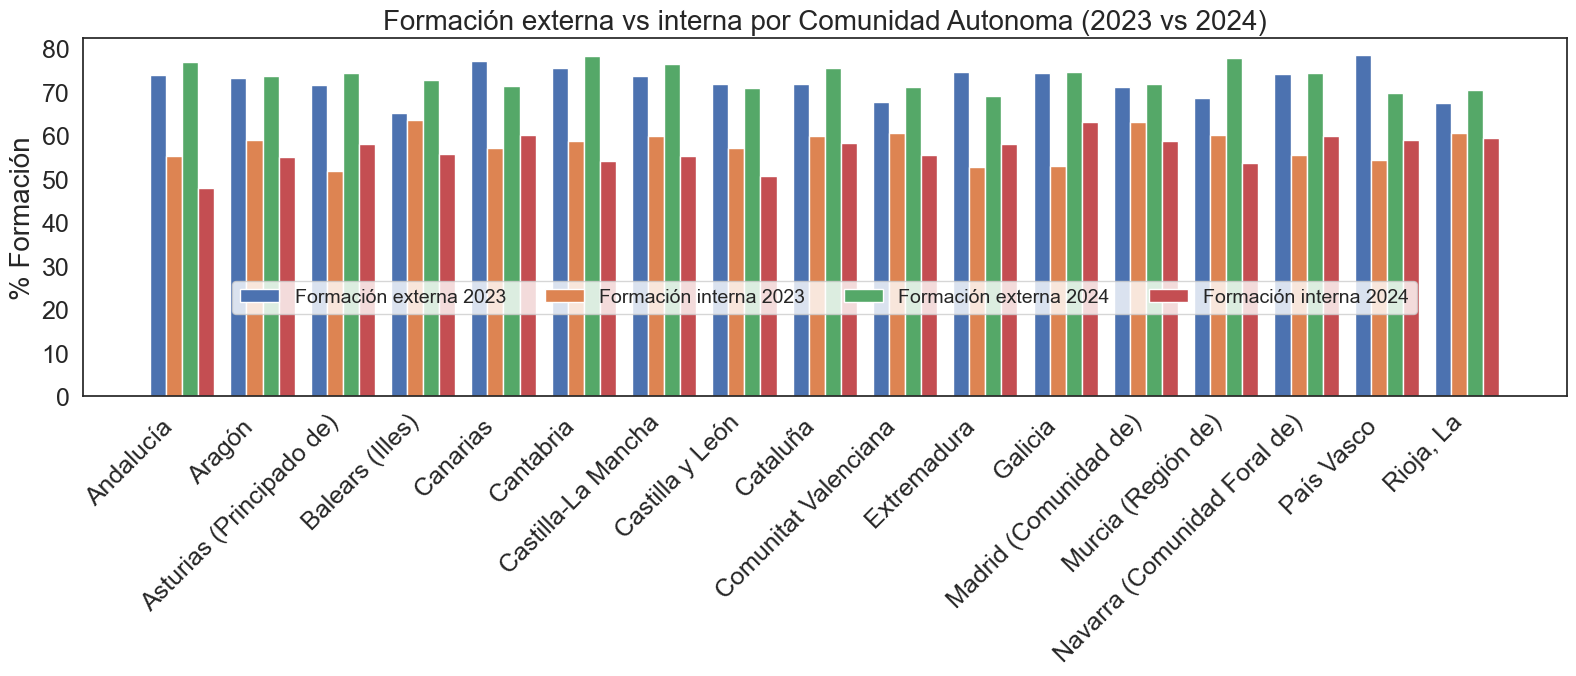

In [1704]:
col1 = 'Cursos de formación diseñados y gestionados por otra organización'
col2 = 'Formación planificada en el puesto de trabajo, utilizando los medios habituales de trabajo'
df_2023 = df2023_ccaa[df2023_ccaa['año'] == 2023][['categoria', col1, col2]].copy()
df_2023 = df_2023.rename(columns={col1: 'Formación externa_2023', col2: 'Formación interna_2023'})

df_2024 = df2024_ccaa[df2024_ccaa['año'] == 2024][['categoria', col1, col2]].copy()
df_2024 = df_2024.rename(columns={col1: 'Formación externa_2024', col2: 'Formación interna_2024'})
df_ccaa = pd.merge(df_2023, df_2024, on='categoria', how='inner')
x = np.arange(len(df_ccaa['categoria']))
width = 0.2

plt.figure(figsize=(16,7))

# 2023
plt.bar(x - 1.5*width, df_ccaa['Formación externa_2023'], width, label='Formación externa 2023')
plt.bar(x - 0.5*width, df_ccaa['Formación interna_2023'], width, label='Formación interna 2023')

# 2024
plt.bar(x + 0.5*width, df_ccaa['Formación externa_2024'], width, label='Formación externa 2024')
plt.bar(x + 1.5*width, df_ccaa['Formación interna_2024'], width, label='Formación interna 2024')

plt.xticks(x, df_ccaa['categoria'], rotation=45, ha='right', fontsize=18)
plt.yticks(fontsize=18)
plt.ylabel('% Formación', fontsize=20)
plt.title('Formación externa vs interna por Comunidad Autonoma (2023 vs 2024)', fontsize=20)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.35), ncol=4, fontsize=14)
plt.tight_layout()
plt.show()